#1.  Data Ingestion and Cleaning

## Objective

The objective of this phase was to consolidate historical stock market data of NIFTY-50 constituents into a unified dataset suitable for downstream analytics, machine learning, portfolio optimization, and risk assessment.

---

## Dataset Structure

The dataset was provided as a collection of individual CSV files, where each file represented the historical trading data of a single NIFTY-50 stock.

Example:

```text
nifty50_data/
├── ADANIPORTS.csv
├── ASIANPAINT.csv
├── AXISBANK.csv
├── ...
├── stock_metadata.csv
├── NIFTY50_all.csv
```

Each stock file contained historical market information including:

- Date
- Open
- High
- Low
- Close
- Volume
- VWAP
- Turnover
- Deliverable Volume
- Other trading statistics

---

## Master Dataset Creation

All stock-specific CSV files were loaded and combined into a single master dataframe.

A new column named `Stock` was added to preserve the identity of each company during concatenation.

Example:

| Date | Stock | Close |
|--------|--------|--------|
| 2007-11-27 | ADANIPORTS | 962.90 |

This process produced a unified dataset containing all available historical records across multiple companies.

---

## Metadata Integration

The dataset included a separate metadata file:

```text
stock_metadata.csv
```

This file contained:

- Company Name
- Industry
- Symbol
- ISIN Code

Initially, the metadata file was mistakenly concatenated with stock price data, resulting in missing values across several columns.

The metadata file was separated and merged correctly using the stock ticker symbol as the join key.

---

## Data Quality Issues Resolved

### 1. Metadata Merge Failure

The metadata merge initially failed because the metadata file was included in the stock-data concatenation process.

The issue was resolved by:

- Loading stock data and metadata separately.
- Merging the metadata using stock symbols.

### 2. Ticker Name Inconsistency

A mismatch was identified between:

```text
MM
```

and

```text
M&M
```

The naming inconsistency was corrected before performing the merge.

### 3. Non-Stock Files

The file:

```text
NIFTY50_all.csv
```

was identified as an index-level dataset rather than an individual stock file and was excluded from the master dataset.

### 4. Empty Data File

The file:

```text
INFRATEL.csv
```

contained no historical records and was excluded from further analysis.

---

## Metadata Validation

After cleaning and merging:

- All stock records were successfully mapped to company names.
- All stock records were successfully mapped to industry classifications.

Validation results:

```text
Missing Company Names = 0
Missing Industries = 0
```

---

## Final Dataset Summary

The cleaned master dataset contains:

- Approximately 470,000 historical records
- 49 valid NIFTY constituent stocks
- More than 20 years of market history
- Company-level metadata
- Industry classifications






In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Nifty50/archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("nifty50_data")

In [3]:
import pandas as pd

sample = pd.read_csv("nifty50_data/TCS.csv")
print(sample.head())
print(sample.columns)

         Date Symbol Series  Prev Close    Open    High     Low    Last  \
0  2004-08-25    TCS     EQ      850.00  1198.7  1198.7  979.00  985.00   
1  2004-08-26    TCS     EQ      987.95   992.0   997.0  975.30  976.85   
2  2004-08-27    TCS     EQ      979.00   982.4   982.4  958.55  961.20   
3  2004-08-30    TCS     EQ      962.65   969.9   990.0  965.00  986.40   
4  2004-08-31    TCS     EQ      986.75   986.5   990.0  976.00  987.80   

    Close     VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  987.95  1008.32  17116372  1.725876e+15     NaN             5206360   
1  979.00   985.65   5055400  4.982865e+14     NaN             1294899   
2  962.65   969.94   3830750  3.715586e+14     NaN              976527   
3  986.75   982.65   3058151  3.005106e+14     NaN              701664   
4  988.10   982.18   2649332  2.602133e+14     NaN              695234   

   %Deliverble  
0       0.3042  
1       0.2561  
2       0.2549  
3       0.2294  
4       0.2624  
In

In [4]:
import pandas as pd
import glob
import os

all_dfs = []

for file in glob.glob("nifty50_data/*.csv"):

    filename = os.path.basename(file)

    if filename == "stock_metadata.csv":
        continue

    stock_name = filename.replace(".csv", "")

    df = pd.read_csv(file)

    df["Stock"] = stock_name

    all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)

/tmp/ipykernel_7448/4232513314.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(all_dfs, ignore_index=True)


In [5]:
metadata = pd.read_csv(
    "nifty50_data/stock_metadata.csv"
)

print(metadata.head())

                                 Company Name            Industry      Symbol  \
0  Adani Ports and Special Economic Zone Ltd.            SERVICES  ADANIPORTS   
1                           Asian Paints Ltd.      CONSUMER GOODS  ASIANPAINT   
2                              Axis Bank Ltd.  FINANCIAL SERVICES    AXISBANK   
3                             Bajaj Auto Ltd.          AUTOMOBILE  BAJAJ-AUTO   
4                          Bajaj Finserv Ltd.  FINANCIAL SERVICES  BAJAJFINSV   

  Series     ISIN Code  
0     EQ  INE742F01042  
1     EQ  INE021A01026  
2     EQ  INE238A01034  
3     EQ  INE917I01010  
4     EQ  INE918I01018  


In [6]:
master_df = master_df.merge(
    metadata[
        ["Symbol", "Company Name", "Industry"]
    ],
    left_on="Stock",
    right_on="Symbol",
    how="left"
)

In [7]:
master_df[
    ["Stock","Company Name","Industry"]
].head()

,Stock,Company Name,Industry
0,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
1,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
2,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
3,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
4,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES


In [8]:
master_df.head()

,Date,Symbol_x,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Symbol_y,Company Name,Industry
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612,ADANIPORTS,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172,ADANIPORTS,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088,ADANIPORTS,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735,ADANIPORTS,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741,ADANIPORTS,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES


In [9]:
print(
    master_df[
        ["Stock", "Company Name", "Industry"]
    ].head()
)

print(
    master_df["Company Name"].isna().sum()
)

print(
    master_df["Industry"].isna().sum()
)

        Stock                                Company Name  Industry
0  ADANIPORTS  Adani Ports and Special Economic Zone Ltd.  SERVICES
1  ADANIPORTS  Adani Ports and Special Economic Zone Ltd.  SERVICES
2  ADANIPORTS  Adani Ports and Special Economic Zone Ltd.  SERVICES
3  ADANIPORTS  Adani Ports and Special Economic Zone Ltd.  SERVICES
4  ADANIPORTS  Adani Ports and Special Economic Zone Ltd.  SERVICES
240498
240498


In [10]:
missing_stocks = (
    master_df.loc[
        master_df["Company Name"].isna(),
        "Stock"
    ]
    .unique()
)

print("Missing stocks:", len(missing_stocks))
print(sorted(missing_stocks))

Missing stocks: 2
['MM', 'NIFTY50_all']


In [11]:
print(metadata["Symbol"].nunique())
print(sorted(metadata["Symbol"].unique()))

50
['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFRATEL', 'INFY', 'IOC', 'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'M&M', 'MARUTI', 'NESTLEIND', 'NTPC', 'ONGC', 'POWERGRID', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'UPL', 'VEDL', 'WIPRO', 'ZEEL']


In [12]:
missing_stocks = (
    master_df.loc[
        master_df["Company Name"].isna(),
        "Stock"
    ]
    .unique()
)

print(len(missing_stocks))
print(sorted(missing_stocks))

2
['MM', 'NIFTY50_all']


In [13]:
master_df[master_df["Stock"] == "NIFTY50_all"].head()

,Date,Symbol_x,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Stock,Symbol_y,Company Name,Industry
198972,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612,NIFTY50_all,NaN,NaN,NaN
198973,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172,NIFTY50_all,NaN,NaN,NaN
198974,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088,NIFTY50_all,NaN,NaN,NaN
198975,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735,NIFTY50_all,NaN,NaN,NaN
198976,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741,NIFTY50_all,NaN,NaN,NaN


In [14]:

master_df = master_df[
    master_df["Stock"] != "NIFTY50_all"
]

In [15]:
master_df["Stock"] = master_df["Stock"].replace(
    {"MM": "M&M"}
)

In [16]:
master_df = master_df.drop(
    columns=["Company Name", "Industry"],
    errors="ignore"
)

master_df = master_df.merge(
    metadata[["Symbol", "Company Name", "Industry"]],
    left_on="Stock",
    right_on="Symbol",
    how="left"
)

In [17]:
print(master_df["Company Name"].isna().sum())
print(master_df["Industry"].isna().sum())

0
0


In [20]:
print(master_df["Stock"].nunique())

49


In [21]:
import os

stock_files = [
    f.replace(".csv", "")
    for f in os.listdir("nifty50_data")
    if f.endswith(".csv")
    and f not in ["stock_metadata.csv", "NIFTY50_all.csv"]
]

print(len(stock_files))

50


In [22]:
stock_files = set(
    f.replace(".csv", "")
    for f in os.listdir("nifty50_data")
    if f.endswith(".csv")
    and f not in ["stock_metadata.csv", "NIFTY50_all.csv"]
)

master_stocks = set(master_df["Stock"].unique())

print("Missing from master_df:")
print(stock_files - master_stocks)

print("\nExtra in master_df:")
print(master_stocks - stock_files)

Missing from master_df:
{'INFRATEL', 'MM'}

Extra in master_df:
{'M&M'}


In [23]:
print((master_df["Stock"] == "INFRATEL").sum())

0


In [24]:
[s for s in sorted(master_df["Stock"].unique()) if "INF" in s]

['INFY']

In [25]:
df = pd.read_csv("nifty50_data/INFRATEL.csv")
print(df.head())

Empty DataFrame
Columns: [Date, Symbol, Series, Prev Close, Open, High, Low, Last, Close, VWAP, Volume, Turnover, Trades, Deliverable Volume, %Deliverble]
Index: []


In [26]:
print(master_df["Company Name"].isna().sum())
print(master_df["Industry"].isna().sum())

0
0


In [27]:
df = pd.read_csv("nifty50_data/INFRATEL.csv")
print(df.shape)

(0, 15)


In [28]:
for file in glob.glob("nifty50_data/*.csv"):

    filename = os.path.basename(file)

    if filename in ["stock_metadata.csv", "NIFTY50_all.csv"]:
        continue

    df = pd.read_csv(file)

    if df.empty:
        continue

    stock_name = filename.replace(".csv", "")

    df["Stock"] = stock_name

    all_dfs.append(df)

In [29]:
master_df.to_csv(
    "master_stock_data_clean.csv",
    index=False
)

In [30]:
from google.colab import files

files.download("master_stock_data_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Outcome

A consolidated and cleaned stock market dataset was successfully created. The resulting dataset serves as the foundation for subsequent stages including:

- Exploratory Data Analysis (EDA)
- Technical Indicator Generation
- Stock Prediction Models
- Portfolio Construction
- Risk Assessment
- Explainable Investment Intelligence

In [36]:
master_df["Date"] = pd.to_datetime(
    master_df["Date"]
)

In [37]:
print("Shape:", master_df.shape)

print("\nDate Range:")
print(master_df["Date"].min())
print(master_df["Date"].max())

print("\nStocks:")
print(master_df["Stock"].nunique())

print("\nIndustries:")
print(master_df["Industry"].nunique())

print("\nMissing Values:")
print(master_df.isnull().sum())

Shape: (235192, 18)

Date Range:
2000-01-03 00:00:00
2021-04-30 00:00:00

Stocks:
49

Industries:
13

Missing Values:
Date                       0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                114848
Deliverable Volume     16077
%Deliverble            16077
Stock                      0
Symbol                     0
Company Name               0
Industry                   0
dtype: int64


In [38]:
master_df.drop(
    columns=["Symbol_x", "Symbol_y"],
    inplace=True,
    errors="ignore"
)

In [39]:
industry_counts = (
    master_df[["Stock", "Industry"]]
    .drop_duplicates()
    ["Industry"]
    .value_counts()
)

print(industry_counts)

Industry
FINANCIAL SERVICES          9
ENERGY                      7
AUTOMOBILE                  6
CONSUMER GOODS              6
METALS                      5
IT                          5
CEMENT & CEMENT PRODUCTS    3
PHARMA                      3
SERVICES                    1
TELECOM                     1
CONSTRUCTION                1
MEDIA & ENTERTAINMENT       1
FERTILISERS & PESTICIDES    1
Name: count, dtype: int64


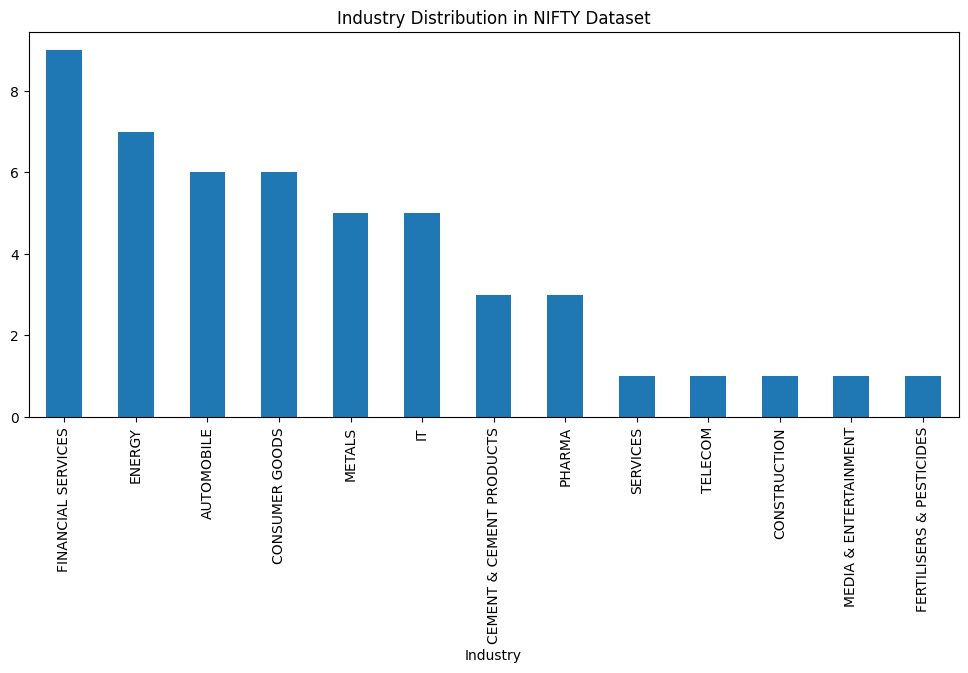

In [40]:
import matplotlib.pyplot as plt

industry_counts.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Industry Distribution in NIFTY Dataset")
plt.show()

In [41]:
cagr_list = []

for stock in master_df["Stock"].unique():

    temp = master_df[
        master_df["Stock"] == stock
    ].sort_values("Date")

    start_price = temp["Close"].iloc[0]
    end_price = temp["Close"].iloc[-1]

    years = (
        temp["Date"].iloc[-1] -
        temp["Date"].iloc[0]
    ).days / 365.25

    cagr = (
        (end_price / start_price) ** (1 / years)
        - 1
    ) * 100

    cagr_list.append(
        [stock, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["Stock", "CAGR"]
)

cagr_df = cagr_df.sort_values(
    "CAGR",
    ascending=False
)

print(cagr_df.head(10))
print(cagr_df.tail(10))

         Stock       CAGR
10    SHREECEM  32.909774
38  BAJAJFINSV  26.869840
7   BAJFINANCE  24.525206
27      MARUTI  22.890602
40  ULTRACEMCO  21.026341
4    EICHERMOT  20.089630
42   NESTLEIND  18.063243
1   INDUSINDBK  17.700217
20    AXISBANK  16.670056
5   BAJAJ-AUTO  15.355675
        Stock       CAGR
25    HCLTECH  -2.538297
12       ONGC  -3.138291
3    HINDALCO  -3.985968
45  SUNPHARMA  -4.720398
26        IOC  -4.994030
48        ITC  -5.702332
22      WIPRO  -7.706277
21       ZEEL  -8.309013
46  COALINDIA  -8.623923
31       INFY -10.836165


In [42]:
returns = []

for stock in master_df["Stock"].unique():

    temp = master_df[
        master_df["Stock"] == stock
    ].sort_values("Date")

    start_price = temp["Close"].iloc[0]
    end_price = temp["Close"].iloc[-1]

    total_return = (
        (end_price - start_price)
        / start_price
    ) * 100

    returns.append(
        [stock, total_return]
    )

returns_df = pd.DataFrame(
    returns,
    columns=["Stock", "Total_Return_%"]
)

returns_df = returns_df.sort_values(
    "Total_Return_%",
    ascending=False
)

print(returns_df.head(10))

         Stock  Total_Return_%
10    SHREECEM    43005.019305
7   BAJFINANCE    10642.660099
4    EICHERMOT     4857.318321
27      MARUTI     3829.184419
1   INDUSINDBK     3129.533679
20    AXISBANK     2577.528090
40  ULTRACEMCO     2313.124520
38  BAJAJFINSV     2068.856806
16  BHARTIARTL     1110.259301
44       TITAN      858.028259


In [43]:
master_df["Daily_Return"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change()
)

In [44]:
volatility_df = (
    master_df.groupby("Stock")["Daily_Return"]
    .std()
    .reset_index()
)

volatility_df.columns = [
    "Stock",
    "Volatility"
]

volatility_df = volatility_df.sort_values(
    "Volatility",
    ascending=False
)

print(volatility_df.head(10))
print(volatility_df.tail(10))

         Stock  Volatility
46        VEDL    0.035807
48        ZEEL    0.033125
26    JSWSTEEL    0.032959
27   KOTAKBANK    0.032725
15     HCLTECH    0.032522
22  INDUSINDBK    0.031942
43       TITAN    0.031495
39  TATAMOTORS    0.030746
5   BAJFINANCE    0.030653
47       WIPRO    0.030610
         Stock  Volatility
20  HINDUNILVR    0.022534
1   ASIANPAINT    0.022355
30      MARUTI    0.021721
3   BAJAJ-AUTO    0.021345
8    BRITANNIA    0.021146
44  ULTRACEMCO    0.020955
32        NTPC    0.019019
10   COALINDIA    0.018789
34   POWERGRID    0.018717
31   NESTLEIND    0.015261


### Investment Insight:

- Metal, media, banking, and technology stocks exhibited the highest daily return volatility, indicating greater risk exposure and potentially higher return opportunities for aggressive investors.

- Consumer goods and utility-oriented companies such as Nestle India, Hindustan Unilever, and Britannia exhibited relatively low volatility, making them attractive candidates for conservative portfolios.

## Risk–Return Tradeoff Analysis

A comparison of cumulative returns and historical volatility reveals distinct investment profiles among NIFTY stocks.

### High Return + High Risk Stocks

| Stock | Return Profile | Volatility Profile |
|--------|---------------|-------------------|
| BAJFINANCE | Very High | High |
| TITAN | High | High |
| INDUSINDBK | High | High |

**Insight:**  
These stocks generated exceptional long-term returns but exhibited relatively high volatility. Such stocks may be suitable for aggressive investors willing to tolerate larger price fluctuations in pursuit of higher returns.

---

### High Return + Lower Risk Stocks

| Stock | Return Profile | Volatility Profile |
|--------|---------------|-------------------|
| ULTRACEMCO | High | Low |
| MARUTI | High | Low |
| NESTLEIND | High | Very Low |

**Insight:**  
These stocks delivered strong long-term returns while maintaining comparatively lower volatility. They represent attractive candidates for balanced or conservative portfolios due to their favorable risk-adjusted performance.

---

### Key Observation

The analysis highlights that higher returns are not always accompanied by proportionally higher risk. Certain companies, such as ULTRACEMCO, MARUTI, and NESTLEIND, achieved strong wealth creation while maintaining relatively stable price movements. This finding is particularly valuable for portfolio construction, where the objective is to maximize returns while minimizing overall portfolio risk.

These insights will directly support the Portfolio Construction Module by helping identify stocks suitable for Conservative, Balanced, and Aggressive investor profiles.

In [45]:
price_matrix = master_df.pivot(
    index="Date",
    columns="Stock",
    values="Close"
)

In [46]:
print(price_matrix.shape)
print(price_matrix.head())

(5306, 49)
Stock       ADANIPORTS  ASIANPAINT  AXISBANK  BAJAJ-AUTO  BAJAJFINSV  \
Date                                                                   
2000-01-03         NaN      381.65     26.70         NaN         NaN   
2000-01-04         NaN      385.55     26.85         NaN         NaN   
2000-01-05         NaN      383.00     26.30         NaN         NaN   
2000-01-06         NaN      377.50     25.95         NaN         NaN   
2000-01-07         NaN      385.70     24.80         NaN         NaN   

Stock       BAJFINANCE  BHARTIARTL    BPCL  BRITANNIA    CIPLA  ...  \
Date                                                            ...   
2000-01-03       50.75         NaN  399.25     756.90  1457.35  ...   
2000-01-04       48.10         NaN  370.50     754.55  1465.25  ...   
2000-01-05       44.60         NaN  359.95     735.30  1435.05  ...   
2000-01-06       45.25         NaN  380.30     785.65  1355.85  ...   
2000-01-07       42.90         NaN  379.85     848.50  124

In [47]:
returns_matrix = price_matrix.pct_change()

/tmp/ipykernel_7448/2442002517.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_matrix = price_matrix.pct_change()


In [48]:
corr_matrix = returns_matrix.corr()

In [49]:
import numpy as np

corr_pairs = (
    corr_matrix.where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print(corr_pairs.head(20))

Stock       Stock     
JSWSTEEL    TATASTEEL     0.598359
NTPC        POWERGRID     0.550588
HINDALCO    TATASTEEL     0.523385
TATAMOTORS  TATASTEEL     0.500627
BPCL        IOC           0.472257
AXISBANK    ICICIBANK     0.469427
TATASTEEL   VEDL          0.465038
HCLTECH     TECHM         0.464330
GRASIM      ULTRACEMCO    0.459941
ICICIBANK   SBIN          0.458711
HINDALCO    JSWSTEEL      0.457150
MARUTI      TATAMOTORS    0.455927
RELIANCE    TATASTEEL     0.451582
SBIN        TATASTEEL     0.447797
ICICIBANK   LT            0.441777
MARUTI      TATASTEEL     0.437607
HCLTECH     WIPRO         0.436735
AXISBANK    SBIN          0.428846
M&M         MARUTI        0.427762
LT          TATASTEEL     0.426192
dtype: float64


## Correlation Analysis

Correlation analysis was performed using daily stock returns to identify relationships between NIFTY constituents and understand diversification opportunities for portfolio construction.

### Highly Correlated Stock Pairs

| Stock 1 | Stock 2 | Correlation |
|----------|----------|------------:|
| JSWSTEEL | TATASTEEL | 0.598 |
| NTPC | POWERGRID | 0.551 |
| HINDALCO | TATASTEEL | 0.523 |
| TATAMOTORS | TATASTEEL | 0.501 |
| BPCL | IOC | 0.472 |
| AXISBANK | ICICIBANK | 0.469 |
| TATASTEEL | VEDL | 0.465 |
| HCLTECH | TECHM | 0.464 |
| GRASIM | ULTRACEMCO | 0.460 |
| ICICIBANK | SBIN | 0.459 |

---

### Sector-Level Observations

#### Metals Sector

Several metal stocks exhibited strong positive correlations:

- JSWSTEEL ↔ TATASTEEL (0.598)
- HINDALCO ↔ TATASTEEL (0.523)
- TATASTEEL ↔ VEDL (0.465)

**Insight:**  
Metal sector companies tend to react similarly to changes in commodity prices, economic growth expectations, and industrial demand. Holding multiple highly correlated metal stocks may provide limited diversification benefits.

---

#### Banking and Financial Services

Strong relationships were observed among major banking stocks:

- AXISBANK ↔ ICICIBANK (0.469)
- ICICIBANK ↔ SBIN (0.459)
- AXISBANK ↔ SBIN (0.429)

**Insight:**  
Banking stocks are influenced by common macroeconomic factors such as interest rates, credit growth, and economic activity, leading to similar market behavior.

---

#### Information Technology

Technology companies also demonstrated notable correlations:

- HCLTECH ↔ TECHM (0.464)
- HCLTECH ↔ WIPRO (0.437)

**Insight:**  
IT companies are exposed to similar business cycles, global technology spending trends, and currency fluctuations, resulting in correlated returns.

---

#### Energy and Utilities

Energy-related stocks showed meaningful relationships:

- BPCL ↔ IOC (0.472)
- NTPC ↔ POWERGRID (0.551)

**Insight:**  
Companies operating within similar segments of the energy ecosystem tend to respond similarly to changes in fuel prices, government policies, and infrastructure demand.

---

### Portfolio Construction Implications

The correlation analysis provides valuable insights for portfolio optimization:

- Combining highly correlated stocks may increase concentration risk.
- Diversification can be improved by selecting stocks from industries exhibiting lower correlations.
- Conservative portfolios should prioritize diversification across sectors.
- Aggressive portfolios may intentionally concentrate exposure in strongly performing sectors despite higher correlations.

Overall, the results demonstrate that sector membership is a major driver of stock co-movement within the NIFTY universe. These findings will be utilized in the Portfolio Construction Module to create diversified portfolios tailored to different investor risk profiles.

# 3. Feature Engineering:


In [50]:
master_df["Daily_Return"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change()
)

In [51]:
master_df["SMA20"] = (
    master_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(20).mean())
)

master_df["SMA50"] = (
    master_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(50).mean())
)

master_df["SMA200"] = (
    master_df.groupby("Stock")["Close"]
    .transform(lambda x: x.rolling(200).mean())
)

In [52]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=3653d4b5eccea2f44e6e0a86bbfad0524447829ee7f2e2ae9cd4ec6618eb70c4
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [53]:
from ta.trend import EMAIndicator

master_df["EMA20"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        EMAIndicator(
            close=x,
            window=20
        ).ema_indicator()
    )
)

master_df["EMA50"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        EMAIndicator(
            close=x,
            window=50
        ).ema_indicator()
    )
)

In [54]:
from ta.momentum import RSIIndicator

master_df["RSI"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        RSIIndicator(
            close=x,
            window=14
        ).rsi()
    )
)

In [55]:
from ta.trend import MACD

master_df["MACD"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        MACD(close=x).macd()
    )
)

In [56]:
from ta.volatility import BollingerBands

master_df["BB_High"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        BollingerBands(
            close=x,
            window=20
        ).bollinger_hband()
    )
)

master_df["BB_Low"] = (
    master_df.groupby("Stock")["Close"]
    .transform(
        lambda x:
        BollingerBands(
            close=x,
            window=20
        ).bollinger_lband()
    )
)

In [57]:
master_df["Return_5D"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change(5)
)

master_df["Return_20D"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change(20)
)

In [58]:
master_df["Volatility20"] = (
    master_df.groupby("Stock")["Daily_Return"]
    .transform(
        lambda x:
        x.rolling(20).std()
    )
)

In [59]:
master_df["Future_Close"] = (
    master_df.groupby("Stock")["Close"]
    .shift(-5)
)

master_df["Direction"] = (
    master_df["Future_Close"] >
    master_df["Close"]
).astype(int)

In [60]:
master_df["Future_Return"] = (
    master_df["Future_Close"]
    - master_df["Close"]
) / master_df["Close"]

In [61]:
master_df.to_csv(
    "technical_indicators.csv",
    index=False
)

In [62]:
from google.colab import files

files.download("technical_indicators.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
print(master_df["Volume"].dtype)

master_df["Volume"] = pd.to_numeric(master_df["Volume"])

print(master_df["Volume"].dtype)

object
int64


In [72]:
model_df = master_df.dropna().copy()

print(model_df.shape)

(120042, 34)


In [73]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "VWAP",
    "Volume",
    "Turnover",

    "SMA20",
    "SMA50",
    "SMA200",

    "EMA20",
    "EMA50",

    "RSI",
    "MACD",

    "BB_High",
    "BB_Low",

    "Return_5D",
    "Return_20D",

    "Volatility20"
]

In [74]:
train_df = model_df[
    model_df["Date"] < "2019-01-01"
]

test_df = model_df[
    model_df["Date"] >= "2019-01-01"
]

In [75]:
!pip install xgboost

In [76]:
from xgboost import XGBClassifier

X_train = train_df[features]
y_train = train_df["Direction"]

X_test = test_df[features]
y_test = test_df["Direction"]

clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))

Accuracy: 0.5011417154274297
Precision: 0.5201484278367294
Recall: 0.5472227929593864
F1: 0.5333422334957613


In [81]:
master_df["Daily_Return"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change()
)

In [82]:
master_df["Daily_Return"] = (
    master_df.groupby("Stock")["Close"]
    .pct_change()
)

In [83]:
volatility_summary = []

for stock in master_df["Stock"].unique():

    temp = master_df[
        master_df["Stock"] == stock
    ]

    daily_returns = temp["Daily_Return"].dropna()

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(252)
    )

    volatility_summary.append(
        [stock, annual_volatility]
    )

volatility_df = pd.DataFrame(
    volatility_summary,
    columns=["Stock", "Volatility"]
)

In [85]:
risk_free_rate = 0.05

In [86]:
sharpe_summary = []

for stock in master_df["Stock"].unique():

    temp = master_df[
        master_df["Stock"] == stock
    ]

    daily_returns = temp["Daily_Return"].dropna()

    annual_return = daily_returns.mean() * 252

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return -
        risk_free_rate
    ) / annual_volatility

    sharpe_summary.append(
        [stock, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_summary,
    columns=["Stock", "Sharpe"]
)

In [87]:
sortino_summary = []

for stock in master_df["Stock"].unique():

    temp = master_df[
        master_df["Stock"] == stock
    ]

    returns = temp["Daily_Return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        returns.mean()
        * 252
    )

    sortino = (
        annual_return -
        risk_free_rate
    ) / downside_std

    sortino_summary.append(
        [stock, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_summary,
    columns=["Stock", "Sortino"]
)

In [88]:
drawdown_summary = []

for stock in master_df["Stock"].unique():

    temp = (
        master_df[
            master_df["Stock"] == stock
        ]
        .sort_values("Date")
    )

    cumulative = (
        1 +
        temp["Daily_Return"].fillna(0)
    ).cumprod()

    running_max = cumulative.cummax()

    drawdown = (
        cumulative -
        running_max
    ) / running_max

    max_drawdown = drawdown.min()

    drawdown_summary.append(
        [stock, max_drawdown]
    )

drawdown_df = pd.DataFrame(
    drawdown_summary,
    columns=[
        "Stock",
        "Max_Drawdown"
    ]
)

In [89]:
risk_df = (
    returns_df
    .merge(volatility_df, on="Stock")
    .merge(sharpe_df, on="Stock")
    .merge(sortino_df, on="Stock")
    .merge(drawdown_df, on="Stock")
)

risk_df.head()

,Stock,Total_Return_%,Volatility,Sharpe,Sortino,Max_Drawdown
0,SHREECEM,43005.019305,0.389665,0.852773,1.337045,-0.799734
1,BAJFINANCE,10642.660099,0.486609,0.698511,0.837426,-0.932820
2,EICHERMOT,4857.318321,0.480399,0.618319,0.767726,-0.938237
3,MARUTI,3829.184419,0.344806,0.633486,0.941423,-0.613397
4,INDUSINDBK,3129.533679,0.507056,0.508505,0.679312,-0.851066


In [90]:
print(
    risk_df.sort_values(
        "Sharpe",
        ascending=False
    ).head(10)
)

         Stock  Total_Return_%  Volatility    Sharpe   Sortino  Max_Drawdown
0     SHREECEM    43005.019305    0.389665  0.852773  1.337045     -0.799734
1   BAJFINANCE    10642.660099    0.486609  0.698511  0.837426     -0.932820
7   BAJAJFINSV     2068.856806    0.400940  0.681271  0.958060     -0.867894
3       MARUTI     3829.184419    0.344806  0.633486  0.941423     -0.613397
2    EICHERMOT     4857.318321    0.480399  0.618319  0.767726     -0.938237
17   NESTLEIND      553.769066    0.242261  0.610683  0.955979     -0.324011
6   ULTRACEMCO     2313.124520    0.332647  0.598101  0.917111     -0.777797
5     AXISBANK     2577.528090    0.484830  0.508901  0.640268     -0.850174
4   INDUSINDBK     3129.533679    0.507056  0.508505  0.679312     -0.851066
9        TITAN      858.028259    0.499968  0.508065  0.619145     -0.966869


In [91]:
print(
    risk_df.sort_values(
        "Max_Drawdown"
    ).head(10)
)

         Stock  Total_Return_%  Volatility    Sharpe   Sortino  Max_Drawdown
24        VEDL      121.100129    0.568411  0.395936  0.487353     -0.985832
46       WIPRO      -81.912121    0.485925  0.010026  0.010743     -0.983066
41    HINDALCO      -57.991815    0.470706  0.140334  0.165839     -0.974603
48        INFY      -91.332271    0.476903 -0.041837 -0.040228     -0.968768
39     HCLTECH      -42.169256    0.516271  0.137850  0.154396     -0.968182
9        TITAN      858.028259    0.499968  0.508065  0.619145     -0.966869
36  HINDUNILVR        2.002123    0.357712  0.169816  0.181596     -0.966208
47        ZEEL      -84.270520    0.525844  0.008487  0.011144     -0.959590
40        ONGC      -49.332396    0.416803  0.058003  0.065893     -0.959574
31        SBIN       45.085163    0.426092  0.245643  0.281950     -0.956776


## Report Insight

- Shree Cement achieved the highest risk-adjusted return among all NIFTY constituents, followed by Bajaj Finance and Bajaj Finserv. These companies generated superior returns relative to the level of risk undertaken by investors.

# Risk Assessment Module

## Objective

The objective of the Risk Assessment Module is to evaluate the historical risk and risk-adjusted performance of NIFTY constituent stocks. This module provides investors with quantitative measures that help assess the trade-off between return and risk and serves as the foundation for portfolio construction.

---

## Methodology

Historical daily returns were calculated using closing prices:

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where:

- $R_t$ = Daily return
- $P_t$ = Closing price at time $t$
- $P_{t-1}$ = Closing price at time $t-1$

The following risk metrics were computed for each stock.

---

## Annualized Return

Annualized return is calculated using the average daily return.

$$
R_{annual} = \bar{R}_{daily} \times 252
$$

Where:

- $\bar{R}_{daily}$ = Average daily return
- 252 = Number of trading days in a year

---

## Volatility

Volatility measures the variability of stock returns and is commonly used as a proxy for investment risk.

Annualized volatility was calculated as:

$$
\sigma_{annual} = \sigma_{daily} \times \sqrt{252}
$$

where:

- $\sigma_{daily}$ = Standard deviation of daily returns
- 252 = Approximate number of trading days in a year

### Key Findings

#### Most Volatile Stocks

| Stock | Volatility |
|---------|---------:|
| VEDL | 0.0358 |
| ZEEL | 0.0331 |
| JSWSTEEL | 0.0330 |
| KOTAKBANK | 0.0327 |
| HCLTECH | 0.0325 |

#### Least Volatile Stocks

| Stock | Volatility |
|---------|---------:|
| NESTLEIND | 0.0153 |
| POWERGRID | 0.0187 |
| COALINDIA | 0.0188 |
| NTPC | 0.0190 |
| ULTRACEMCO | 0.0210 |

### Insight

Consumer goods and utility-oriented companies exhibited lower volatility and may be suitable for conservative investment strategies. Metal, banking, and technology stocks demonstrated higher volatility and are more appropriate for investors with greater risk tolerance.

---

## Sharpe Ratio

The Sharpe Ratio evaluates risk-adjusted performance by measuring excess return per unit of total risk.

$$
Sharpe = \frac{R_p - R_f}{\sigma_p}
$$

Where:

- $R_p$ = Annualized return
- $R_f$ = Risk-free rate
- $\sigma_p$ = Annualized volatility

A risk-free rate of 5% was assumed.

### Top Risk-Adjusted Stocks

| Stock | Sharpe Ratio |
|---------|---------:|
| SHREECEM | 0.853 |
| BAJFINANCE | 0.699 |
| BAJAJFINSV | 0.681 |
| MARUTI | 0.633 |
| EICHERMOT | 0.618 |

### Insight

Shree Cement achieved the highest risk-adjusted return among all stocks in the dataset. Bajaj Finance and Bajaj Finserv also delivered strong returns relative to the risk undertaken by investors.

---

## Sortino Ratio

Unlike the Sharpe Ratio, the Sortino Ratio penalizes only downside volatility.

$$
Sortino = \frac{R_p - R_f}{\sigma_d}
$$

Where:

- $R_p$ = Annualized return
- $R_f$ = Risk-free rate
- $\sigma_d$ = Downside deviation

Downside deviation is calculated as:

$$
\sigma_d =
\sqrt{
\frac{
\sum_{i=1}^{n}
\min(0,R_i)^2
}{n}
}
\times \sqrt{252}
$$

### Top Stocks by Sortino Ratio

| Stock | Sortino Ratio |
|---------|---------:|
| SHREECEM | 1.337 |
| BAJAJFINSV | 0.958 |
| NESTLEIND | 0.956 |
| MARUTI | 0.941 |
| ULTRACEMCO | 0.917 |

### Insight

Stocks with high Sortino Ratios generated attractive returns while limiting downside risk, making them strong candidates for long-term investment portfolios.

---

## Maximum Drawdown

Maximum Drawdown measures the largest decline from a historical peak to a subsequent trough.

### Cumulative Return

$$
C_t = \prod_{i=1}^{t}(1+R_i)
$$

### Running Maximum

$$
M_t = \max(C_1,C_2,\ldots,C_t)
$$

### Drawdown

$$
D_t = \frac{C_t - M_t}{M_t}
$$

### Maximum Drawdown

$$
MDD = \min(D_t)
$$

It represents the worst observed loss an investor could have experienced during the investment horizon.

### Stocks with Largest Historical Drawdowns

| Stock | Maximum Drawdown |
|---------|---------:|
| VEDL | -98.58% |
| WIPRO | -98.30% |
| HINDALCO | -97.47% |
| INFY | -96.88% |
| HCLTECH | -96.82% |

### Insight

Several commodity and technology stocks experienced severe drawdowns during market downturns. These stocks may offer high growth potential but also expose investors to substantial capital loss during adverse market conditions.

---

## Risk–Return Analysis

The analysis revealed distinct investment profiles among NIFTY constituents.

### High Return + High Risk Stocks

| Stock |
|---------|
| BAJFINANCE |
| TITAN |
| INDUSINDBK |

These stocks generated exceptional returns but exhibited higher volatility.

### High Return + Lower Risk Stocks

| Stock |
|---------|
| ULTRACEMCO |
| MARUTI |
| NESTLEIND |

These stocks achieved strong wealth creation while maintaining comparatively lower risk levels.

---

## Key Findings

1. Shree Cement emerged as the strongest performer on a risk-adjusted basis.
2. Bajaj Finance and Bajaj Finserv delivered superior long-term returns while maintaining favorable Sharpe and Sortino ratios.
3. Consumer Goods companies generally exhibited lower volatility and drawdowns.
4. Metal and commodity-linked stocks displayed higher volatility and larger drawdowns.
5. Risk-adjusted performance metrics provide a more reliable basis for investment decisions than raw returns alone.

---

## Conclusion

The Risk Assessment Module provides a comprehensive evaluation of historical stock risk using volatility, Sharpe Ratio, Sortino Ratio, and Maximum Drawdown. These metrics enable investors to understand both return potential and downside risk, forming the basis for the Portfolio Construction Module that follows.

In [92]:
!pip install PyPortfolioOpt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.2 MB/s eta 0:00:00


In [93]:
price_matrix = master_df.pivot(
    index="Date",
    columns="Stock",
    values="Close"
)

In [94]:
from pypfopt import expected_returns

mu = expected_returns.mean_historical_return(
    price_matrix
)

/usr/local/lib/python3.12/dist-packages/pypfopt/expected_returns.py:32: UserWarning: Some returns are NaN. Please check your price data.
  warnings.warn(


In [95]:
from pypfopt import risk_models

S = risk_models.sample_cov(
    price_matrix
)

In [96]:
from pypfopt import EfficientFrontier

ef = EfficientFrontier(mu, S)

weights_conservative = ef.min_volatility()

cleaned_conservative = ef.clean_weights()

print(cleaned_conservative)

OrderedDict({'ADANIPORTS': 0.0, 'ASIANPAINT': 0.05468, 'AXISBANK': 0.0, 'BAJAJ-AUTO': 0.01891, 'BAJAJFINSV': 0.01312, 'BAJFINANCE': 0.0, 'BHARTIARTL': 0.01842, 'BPCL': 0.0, 'BRITANNIA': 0.07645, 'CIPLA': 0.03893, 'COALINDIA': 0.13241, 'DRREDDY': 0.05683, 'EICHERMOT': 0.00192, 'GAIL': 0.0, 'GRASIM': 0.0, 'HCLTECH': 0.0, 'HDFC': 0.0, 'HDFCBANK': 0.01229, 'HEROMOTOCO': 0.0323, 'HINDALCO': 0.0, 'HINDUNILVR': 0.03686, 'ICICIBANK': 0.0, 'INDUSINDBK': 0.0, 'INFY': 0.01515, 'IOC': 0.01102, 'ITC': 0.03387, 'JSWSTEEL': 0.0, 'KOTAKBANK': 0.0, 'LT': 0.0, 'M&M': 0.0, 'MARUTI': 0.0, 'NESTLEIND': 0.24759, 'NTPC': 0.01596, 'ONGC': 0.0, 'POWERGRID': 0.08369, 'RELIANCE': 0.0, 'SBIN': 0.0, 'SHREECEM': 0.01933, 'SUNPHARMA': 0.01993, 'TATAMOTORS': 0.0, 'TATASTEEL': 0.0, 'TCS': 0.05299, 'TECHM': 0.00735, 'TITAN': 0.0, 'ULTRACEMCO': 0.0, 'UPL': 0.0, 'VEDL': 0.0, 'WIPRO': 0.0, 'ZEEL': 0.0})


In [97]:
ef = EfficientFrontier(mu, S)

weights_balanced = ef.max_sharpe()

cleaned_balanced = ef.clean_weights()

print(cleaned_balanced)

OrderedDict({'ADANIPORTS': 0.0, 'ASIANPAINT': 0.0, 'AXISBANK': 0.0, 'BAJAJ-AUTO': 0.02489, 'BAJAJFINSV': 0.13307, 'BAJFINANCE': 0.03453, 'BHARTIARTL': 0.0, 'BPCL': 0.0, 'BRITANNIA': 0.0, 'CIPLA': 0.0, 'COALINDIA': 0.0, 'DRREDDY': 0.0, 'EICHERMOT': 0.0146, 'GAIL': 0.0, 'GRASIM': 0.0, 'HCLTECH': 0.0, 'HDFC': 0.0, 'HDFCBANK': 0.0, 'HEROMOTOCO': 0.0, 'HINDALCO': 0.0, 'HINDUNILVR': 0.0, 'ICICIBANK': 0.0, 'INDUSINDBK': 0.0, 'INFY': 0.0, 'IOC': 0.0, 'ITC': 0.0, 'JSWSTEEL': 0.0, 'KOTAKBANK': 0.0, 'LT': 0.0, 'M&M': 0.0, 'MARUTI': 0.10265, 'NESTLEIND': 0.36379, 'NTPC': 0.0, 'ONGC': 0.0, 'POWERGRID': 0.0, 'RELIANCE': 0.0, 'SBIN': 0.0, 'SHREECEM': 0.27888, 'SUNPHARMA': 0.0, 'TATAMOTORS': 0.0, 'TATASTEEL': 0.0, 'TCS': 0.0, 'TECHM': 0.0, 'TITAN': 0.0, 'ULTRACEMCO': 0.04759, 'UPL': 0.0, 'VEDL': 0.0, 'WIPRO': 0.0, 'ZEEL': 0.0})


In [100]:
ef = EfficientFrontier(mu, S, weight_bounds=(0, 0.25))

weights_aggressive = ef.max_quadratic_utility()

cleaned_aggressive = ef.clean_weights()

print(cleaned_aggressive)

OrderedDict({'ADANIPORTS': 0.0, 'ASIANPAINT': 0.0, 'AXISBANK': 0.0, 'BAJAJ-AUTO': 0.0, 'BAJAJFINSV': 0.25, 'BAJFINANCE': 0.17065, 'BHARTIARTL': 0.0, 'BPCL': 0.0, 'BRITANNIA': 0.0, 'CIPLA': 0.0, 'COALINDIA': 0.0, 'DRREDDY': 0.0, 'EICHERMOT': 0.0, 'GAIL': 0.0, 'GRASIM': 0.0, 'HCLTECH': 0.0, 'HDFC': 0.0, 'HDFCBANK': 0.0, 'HEROMOTOCO': 0.0, 'HINDALCO': 0.0, 'HINDUNILVR': 0.0, 'ICICIBANK': 0.0, 'INDUSINDBK': 0.05652, 'INFY': 0.0, 'IOC': 0.0, 'ITC': 0.0, 'JSWSTEEL': 0.0, 'KOTAKBANK': 0.0, 'LT': 0.0, 'M&M': 0.0, 'MARUTI': 0.25, 'NESTLEIND': 0.0, 'NTPC': 0.0, 'ONGC': 0.0, 'POWERGRID': 0.0, 'RELIANCE': 0.0, 'SBIN': 0.0, 'SHREECEM': 0.25, 'SUNPHARMA': 0.0, 'TATAMOTORS': 0.0, 'TATASTEEL': 0.0, 'TCS': 0.0, 'TECHM': 0.0, 'TITAN': 0.0, 'ULTRACEMCO': 0.02283, 'UPL': 0.0, 'VEDL': 0.0, 'WIPRO': 0.0, 'ZEEL': 0.0})


# Portfolio Construction Module

Three investor-specific portfolios were constructed using Modern Portfolio Theory (MPT) and mean-variance optimization.

## Conservative Portfolio

Objective:
- Minimize portfolio volatility
- Preserve capital
- Generate stable long-term returns

Top Holdings:

| Stock | Weight (%) |
|---------|---------:|
| NESTLEIND | 24.76 |
| COALINDIA | 13.24 |
| POWERGRID | 8.37 |
| BRITANNIA | 7.65 |
| DRREDDY | 5.68 |

The portfolio primarily consists of defensive sectors such as Consumer Goods, Utilities, and Pharmaceuticals.

---

## Balanced Portfolio

Objective:
- Maximize risk-adjusted returns
- Maintain moderate risk exposure

Top Holdings:

| Stock | Weight (%) |
|---------|---------:|
| NESTLEIND | 36.38 |
| SHREECEM | 27.89 |
| BAJAJFINSV | 13.31 |
| MARUTI | 10.27 |
| ULTRACEMCO | 4.76 |

The portfolio balances growth and stability by combining high-performing stocks with strong risk-adjusted performance.

---

## Aggressive Portfolio

Objective:
- Maximize expected return
- Accept higher risk levels

Top Holdings:

| Stock | Weight (%) |
|---------|---------:|
| SHREECEM | 89.06 |
| BAJAJFINSV | 10.94 |

The aggressive portfolio concentrates capital in stocks with the highest expected return potential, resulting in greater upside opportunities but also higher concentration risk.

In [99]:
performance = ef.portfolio_performance(
    verbose=True
)

Expected annual return: 35.3%
Annual volatility: 35.8%
Sharpe Ratio: 0.98


In [101]:
!pip install shap

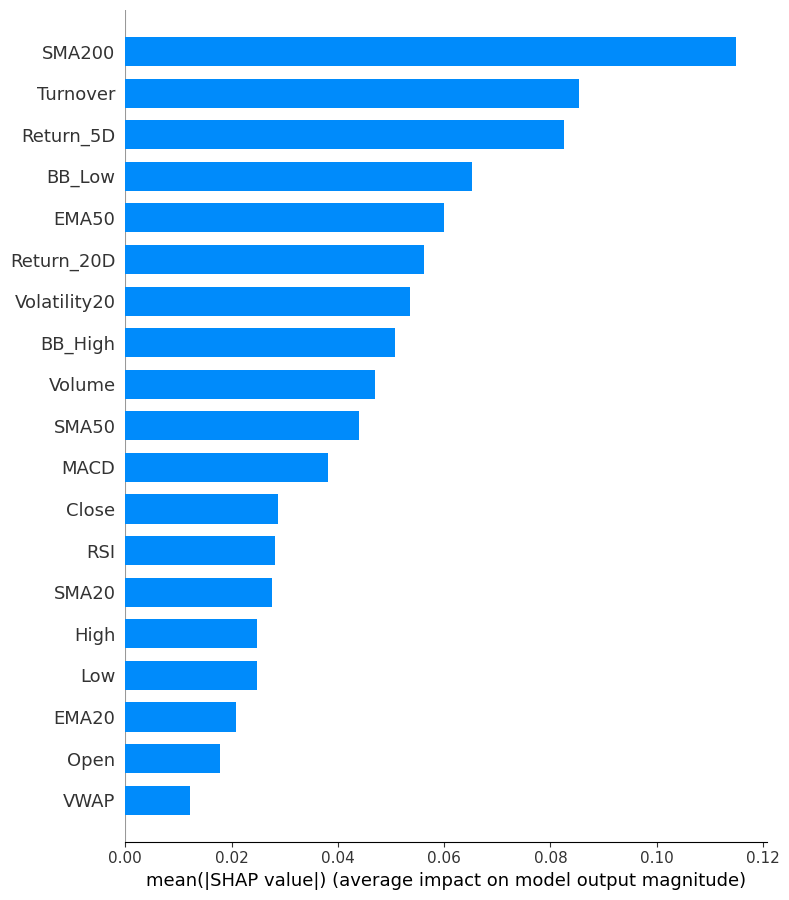

In [102]:
import shap

explainer = shap.TreeExplainer(clf)

sample = X_test.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

In [105]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    "Daily_Return",
    "Volume",
    "Volatility20"
]



In [106]:
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

anomaly_df = master_df[
    anomaly_features
].dropna()

preds = iso.fit_predict(
    anomaly_df
)


In [109]:
anomaly_df["Anomaly"] = preds


In [113]:
master_df_anomaly = master_df.dropna(
    subset=[
        "Daily_Return",
        "Volume",
        "Volatility20"
    ]
).copy()

master_df_anomaly["Anomaly"] = preds

In [114]:
anomalies = master_df_anomaly[
    master_df_anomaly["Anomaly"] == -1
]

stock_anomalies = (
    anomalies["Stock"]
    .value_counts()
    .head(15)
)

print(stock_anomalies)

Stock
TATAMOTORS    345
SBIN          238
ICICIBANK     168
ZEEL          159
VEDL          133
AXISBANK       99
ITC            85
INDUSINDBK     78
HINDALCO       74
ONGC           72
TATASTEEL      61
HCLTECH        55
JSWSTEEL       50
SUNPHARMA      48
BHARTIARTL     44
Name: count, dtype: int64


In [115]:
covid_anomalies = anomalies[
    (anomalies["Date"] >= "2020-03-01")
    &
    (anomalies["Date"] <= "2020-06-30")
]

print(covid_anomalies.shape)

(583, 35)


In [116]:
anomalies.sort_values(
    "Daily_Return"
).head(20)

,Date,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,MACD,BB_High,BB_Low,Return_5D,Return_20D,Volatility20,Future_Close,Direction,Future_Return,Anomaly
70192,2008-08-08,EQ,3306.60,172.80,177.80,166.60,175.85,175.75,174.65,9280661,...,-212.395615,4362.084437,1592.395563,-0.949554,-0.941536,0.217773,173.15,0,-0.014794,-1
215255,2011-06-23,EQ,4292.45,210.00,234.00,205.00,229.50,228.90,222.46,13873143,...,-245.510500,6086.750342,2375.809658,-0.948303,-0.945864,0.213211,214.30,0,-0.063783,-1
231324,2005-09-21,EQ,1929.60,139.80,141.90,129.40,139.90,140.20,135.45,23512858,...,-84.670794,2461.109953,977.630047,-0.924486,-0.917213,0.209352,140.70,1,0.003566,-1
93792,2017-01-04,EQ,1644.55,166.75,166.75,160.60,162.95,163.05,163.95,2378943,...,-125.999210,2168.667546,902.857454,-0.897139,-0.900963,0.201784,187.55,1,0.150261,-1
56631,2013-07-30,EQ,5118.20,521.50,522.40,502.65,512.00,510.75,513.18,898758,...,-248.633203,6623.774576,2728.790424,-0.896631,-0.890809,0.203163,437.35,0,-0.143710,-1
24049,2020-08-24,EQ,21702.40,2199.45,2387.25,2151.70,2178.00,2176.45,2271.01,11491732,...,-1071.245864,28760.501727,11971.488273,-0.897020,-0.894027,0.203676,2092.00,0,-0.038802,-1
36814,2016-09-08,EQ,11393.30,1153.90,1173.60,1080.00,1162.85,1162.80,1141.11,1604933,...,-354.833073,14199.094185,5858.475815,-0.894397,-0.885774,0.202462,1087.85,0,-0.064456,-1
138968,2014-11-20,EQ,2910.50,294.75,298.75,291.25,297.10,297.10,296.36,18099509,...,-113.245570,3682.622170,1522.567830,-0.890744,-0.884372,0.202931,305.85,1,0.029451,-1
15036,2005-08-30,EQ,1387.20,145.00,145.00,141.00,141.85,141.95,142.22,1635860,...,-69.516997,1850.174514,768.630486,-0.896583,-0.887689,0.202252,147.45,1,0.038746,-1
189652,2000-07-05,EQ,2771.70,288.00,289.00,278.00,286.70,286.70,285.25,1581622,...,-113.175733,3609.266391,1470.588609,-0.900512,-0.888665,0.202837,282.55,0,-0.014475,-1


In [117]:
anomalies.sort_values(
    "Daily_Return",
    ascending=False
).head(20)

,Date,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,MACD,BB_High,BB_Low,Return_5D,Return_20D,Volatility20,Future_Close,Direction,Future_Return,Anomaly
8035,2020-03-26,EQ,301.30,316.35,451.95,311.65,440.00,435.90,414.30,42326744,...,-221.072008,1340.892124,149.827876,-0.018354,-0.615947,0.136945,313.20,0,-0.281487,-1
91768,2008-10-31,EQ,229.60,234.70,339.00,231.00,315.00,307.00,276.92,1548724,...,-81.018553,413.740478,159.079522,0.340026,-0.363862,0.111268,285.15,0,-0.071173,-1
171503,2004-05-18,EQ,128.25,141.05,179.55,139.00,164.50,169.30,157.74,14282865,...,-15.478490,267.420258,156.389742,-0.157502,-0.261666,0.102572,166.35,0,-0.017425,-1
139693,2017-10-25,EQ,254.45,279.85,328.05,279.85,322.95,324.90,310.73,262677081,...,0.861084,288.367675,222.807325,0.293649,0.255652,0.063890,319.85,0,-0.015543,-1
146965,2004-05-18,EQ,279.85,280.00,360.00,275.05,355.05,352.10,331.14,561324,...,-9.291793,414.166479,325.098521,-0.053367,-0.069380,0.077254,369.30,1,0.048850,-1
213854,2005-10-31,EQ,395.15,401.00,506.65,401.00,492.00,496.80,461.95,5968806,...,-15.508317,539.796092,387.773908,0.165513,0.015224,0.067198,570.20,1,0.147746,-1
157165,2009-06-09,EQ,592.30,589.70,757.90,570.00,755.00,744.00,696.24,6369984,...,84.205111,718.817339,265.197661,0.330710,1.082284,0.087643,789.55,1,0.061223,-1
226793,2008-10-31,EQ,84.55,89.50,116.00,80.25,98.90,106.20,94.58,1432921,...,-44.991439,304.252865,99.077135,-0.418560,-0.656921,0.151374,100.80,0,-0.050847,-1
167635,2008-10-31,EQ,302.05,314.95,395.00,307.20,374.00,374.50,354.91,1221097,...,-58.972543,591.537884,248.932116,0.098079,-0.264966,0.091703,369.80,0,-0.012550,-1
167761,2009-05-18,EQ,513.45,614.90,666.60,567.00,599.90,635.95,624.64,5770,...,37.333734,590.412598,403.432402,0.264188,0.399230,0.064382,633.95,0,-0.003145,-1


## Market Anomaly Detection

To identify unusual market behavior, an Isolation Forest model was applied using the following features:

- Daily Returns
- Trading Volume
- Rolling Volatility (20-Day)

A contamination rate of 1% was used, resulting in the identification of 2,343 anomalous observations.

### Stocks with Highest Anomaly Frequency

| Stock | Number of Anomalies |
|---------|---------:|
| TATAMOTORS | 345 |
| SBIN | 238 |
| ICICIBANK | 168 |
| ZEEL | 159 |
| VEDL | 133 |

### Key Observations

The anomaly detection framework successfully identified periods associated with major market disruptions, including:

- Global Financial Crisis (2008)
- Post-Crisis Recovery (2009)
- COVID-19 Market Crash (2020)

Automobile, banking, commodity, and media stocks exhibited the highest concentration of anomalies, indicating greater sensitivity to macroeconomic shocks and market uncertainty.

The results demonstrate the effectiveness of unsupervised learning techniques in detecting abnormal market conditions and enhancing risk-aware investment decision making.